In [ ]:
! pip install python-dotenv pandas openai tiktoken matplotlib

In [ ]:
import sys
sys.path.append('..')
sys.path.append('../..')
sys.path.append('ci_cd')
sys.path.append('../../lamoom')
import dotenv
dotenv.load_dotenv('..')
import pandas as pd
results = {}
testing_pipes = {}

In [ ]:
from lamoom import Prompt
from lamoom.ai_models.tools.web_tool import WEB_SEARCH_TOOL

agent = Prompt(id="answer_on_medical_question")

agent.add("""
Answer on the question, make a research if needed.          
Please first think out loud before answering.
""", role="system")

agent.add("""{question}""", role="user")

agent.add_tool(WEB_SEARCH_TOOL)


In [ ]:
from lamoom import Lamoom
client = Lamoom()

In [ ]:
import os
openai_key = os.getenv("OPENAI_API_KEY")

In [ ]:
legal_qa_v1_df = pd.read_csv("hf://datasets/dzunggg/legal-qa-v1/legal_qa_full.csv")
# add index column, add a new column with index for legal_qa_v1_df
legal_qa_v1_df['index'] = legal_qa_v1_df.index
legal_qa_v1_df.head()

In [ ]:
final_df = legal_qa_v1_df.copy()

In [ ]:
ideal_answer_statements = {}

In [ ]:
from researches.ci_cd.TestLLMResponsePipe import TestLLMResponsePipe
from researches.ci_cd.responses import Statement


if not os.path.exists('ideal_answer_statements.json'):
    for index, row in final_df.iterrows():
        id_row = row['index']
        question = row['question']
        answer = row['answer']

        ideal_answer_statements[id_row] = TestLLMResponsePipe.generate_statements(
            question=question,
            ideal_answer=answer
        )
        print(f"Processed row {id_row}: {ideal_answer_statements[id_row]}")
        import json
    with open('ideal_answer_statements.json', 'w') as f:
        formatted_json = {k: [stmt.to_dict() for stmt in v if stmt] for k, v in ideal_answer_statements.items() if v}
        json.dump(formatted_json, f)
else:
    import json
    with open('ideal_answer_statements.json', 'r') as f:
        ideal_answer_statements_json = json.load(f)
    ideal_answer_statements = {int(k): [Statement(**stmt) for stmt in v] for k, v in ideal_answer_statements_json.items()}

In [ ]:

for model in target_models:
    if model not in testing_pipes:
        testing_pipes[model] = TestLLMResponsePipe(lamoom=client)

In [ ]:
target_models_results = target_models_results

Statistics for model gemini/gemini-2.5-pro:
gemini/gemini-2.5-pro (Passing score = 70%, Average=66.92%)


/var/folders/4z/2206htss61q7_vc5rm0lkcs00000gn/T/ipykernel_5166/782821969.py:353: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


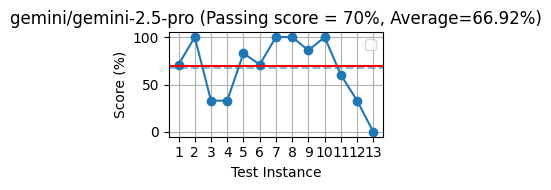

Statistics for model openai/gpt-4.1-mini:
openai/gpt-4.1-mini (Passing score = 70%, Average=59.62%)


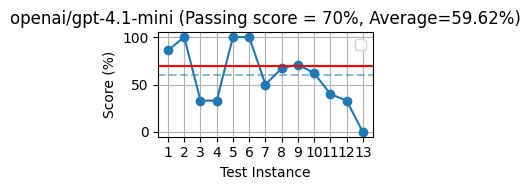

Statistics for model openai/gpt-4.1:
openai/gpt-4.1 (Passing score = 70%, Average=60.54%)


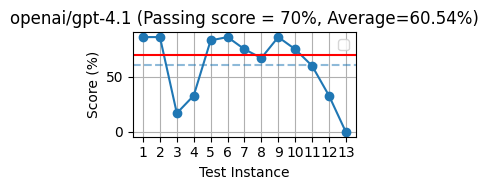

Statistics for model claude/claude-opus-4-1-20250805:
claude/claude-opus-4-1-20250805 (Passing score = 70%, Average=51.62%)


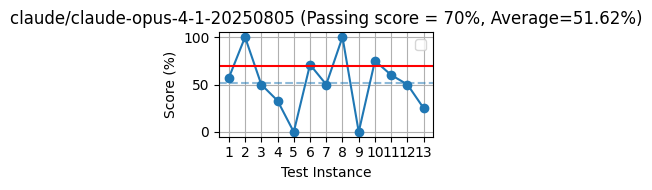

Statistics for model claude/claude-3-7-sonnet-20250219:
claude/claude-3-7-sonnet-20250219 (Passing score = 70%, Average=36.77%)


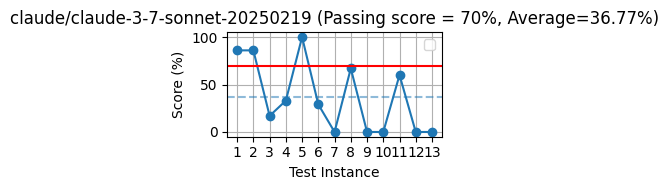

Statistics for model custom/x/grok-4-latest:
custom/x/grok-4-latest (Passing score = 70%, Average=73.46%)


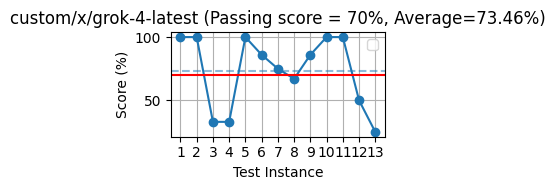

In [ ]:

for target_model in target_models:
    print(f"Statistics for model {target_model}:")
    result = testing_pipes[target_model].accumulated_results
    result = []
    pipe = TestLLMResponsePipe(accumulated_results=result, lamoom=client)
    pipe.visualize_test_results(show_statistics=True, plt_figure_size=(3, 2), title=f"{target_model}")

In [ ]:
target_models_with_tool_call_enabled = [
    "claude/claude-opus-4-1-20250805",
]
testing_pipes_with_tool_call_enabled = {}
for model in target_models_with_tool_call_enabled:
    if model not in testing_pipes_with_tool_call_enabled:
        testing_pipes_with_tool_call_enabled[model] = TestLLMResponsePipe(lamoom=client)

In [ ]:
target_models_with_tool_call_enabled_results = {}

In [ ]:
target_models = [
    "gemini/gemini-2.5-pro",
    "openai/gpt-4.1-mini",
    "openai/gpt-4.1",
    "claude/claude-opus-4-1-20250805",
    "claude/claude-3-7-sonnet-20250219",
    "custom/x/grok-4-latest"
]

In [ ]:

for ideal_answer_statement_ind in ideal_answer_statements:
    for target_model in target_models_with_tool_call_enabled:
        if target_models_with_tool_call_enabled_results.get(ideal_answer_statement_ind) and target_models_with_tool_call_enabled_results[ideal_answer_statement_ind].get(target_model):
            print(f"Skipping already processed model {target_model} for index {ideal_answer_statement_ind}")
            continue
        item = final_df.loc[final_df['index'] == ideal_answer_statement_ind].squeeze()
        question = item['question']
        answer = item['answer']
        response = client.call(agent.id, {"question": question}, model=target_model)
        print(f"Model: {target_model}, Response: {response.content}")

        statements = ideal_answer_statements[ideal_answer_statement_ind]
        result = testing_pipes_with_tool_call_enabled[target_model].compare(
            ideal_answer=answer,
            llm_response=response.content,
            optional_params={'model': target_model, 'index': ideal_answer_statement_ind},
            statements=statements
        )
        if not target_models_with_tool_call_enabled_results.get(ideal_answer_statement_ind):
            target_models_with_tool_call_enabled_results[ideal_answer_statement_ind] = {}
        target_models_with_tool_call_enabled_results[ideal_answer_statement_ind][target_model] = result
        print(f'Result for model {target_model}:\n{result.to_dict()}\n')

    for target_model in target_models_with_tool_call_enabled:
        print(f"Statistics for model {target_model}:")
        testing_pipes_with_tool_call_enabled[target_model].visualize_test_results(group_by="prompt_id")

    if ideal_answer_statement_ind > 20:
        break


In [ ]:

for ideal_answer_statement_ind in ideal_answer_statements:
    for target_model in target_models:
        if target_models_results.get(ideal_answer_statement_ind) and target_models_results[ideal_answer_statement_ind].get(target_model):
            print(f"Skipping already processed model {target_model} for index {ideal_answer_statement_ind}")
            continue
        item = final_df.loc[final_df['index'] == ideal_answer_statement_ind].squeeze()
        question = item['question']
        answer = item['answer']
        response = client.call(agent.id, {"question": question}, model=target_model)
        print(f"Model: {target_model}, Response: {response.content}")

        statements = ideal_answer_statements[ideal_answer_statement_ind]
        result = testing_pipes[target_model].compare(
            ideal_answer=answer,
            llm_response=response.content,
            optional_params={'model': target_model, 'index': ideal_answer_statement_ind},
            statements=statements
        )
        if not target_models_results.get(ideal_answer_statement_ind):
            target_models_results[ideal_answer_statement_ind] = {}
        target_models_results[ideal_answer_statement_ind][target_model] = result
        print(f'Result for model {target_model}:\n{result.to_dict()}\n')

    for target_model in target_models:
        print(f"Statistics for model {target_model}:")
        testing_pipes[target_model].visualize_test_results(group_by="prompt_id")

    if ideal_answer_statement_ind > 20:
        break
